# Introduction

**Customer Segmentation and Clustering Algorithms in Unsupervised Learning**

- First of all, Unsupervised Learning refers to the effort to make observation units meaningful in situations where there is no dependent variable in machine learning models.

- The goal in unsupervised learning is to discover patterns or relationships in the data.

- From this perspective, unsupervised learning is often used for Exploratory Data Analysis (EDA) and can be used to identify patterns or relationships that may not be immediately noticeable when looking at raw data.

- The data we will be working on today contains purchase history data obtained from membership cards given to customers of a large shopping center, and it is desired to segment this data based on these records.

- The data has been previously processed, feature engineered, and is ready for use.

- Using this data, we will divide our customers into clusters or groups using different methods and analyze these groups to derive insights.

- Before that, we will perform EDA to understand and familiarize ourselves with the data, which will help us to perform more accurate clustering.

**1. Introduction:**

- **Domain Knowledge:**
   - In the modern retail world, customer data is invaluable. Shopping malls analyze customer habits, preferences, and demographic information to offer more personalized experiences. Such personalization can enhance customer loyalty and drive sales.

- **Dataset Introduction:**
   - The "Mall_Customers" dataset contains valuable information about shopping mall customers, collected to support this goal. This dataset includes basic demographic and economic information such as customers' age, gender, annual income, and spending.

- **Importance of the Dataset:**
   - Customer segmentation is a critical tool for tailoring marketing strategies and campaigns to individuals. The "Mall_Customers" dataset provides a foundation for this segmentation, offering valuable insights to retailers and marketers.

- **Objective of Our Project:**
   - In this project, we aim to perform customer segmentation using unsupervised learning techniques with the "Mall_Customers" dataset. This segmentation will provide in-depth insights into customer behavior at the shopping mall, offering opportunities to deliver more personalized services.

**2. Features of the Dataset:**
   - **Customer ID:** A unique identifier assigned to each customer.
   - **Gender:** The gender of the customer.

# Tasks

**1. Import Libraries**
- Import Libraries

**2. Exploratory Data Analysis (EDA)**

**3. Cluster Analysiswith K-Means**

- Clustering based on Age and Spending Score

    *i. Create a new dataset with two variables of your choice*
    
    *ii. Determine optimal number of clusters*
    
    *iii. Apply K Means*
    
    *iv. Visualizing and Labeling All the Clusters*
    
    
- Clustering based on Annual Income and Spending Score

    *i. Create a new dataset with two variables of your choice*
    
    *ii. Determine optimal number of clusters*
    
    *iii. Apply K Means*
    
    *iv. Visualizing and Labeling All the Clusters*
    
    
**4. Hierarchical Clustering**

    *i. Determine optimal number of clusters using Dendogram*

    *ii. Apply Agglomerative Clustering*

    *iii. Visualizing and Labeling All the Clusters* 

**5.Conclusion**

# Import Libraries

In [1]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

# Exploratory Data Analysis (EDA)

- There is a large shopping mall in a specific city that maintains information about its customers who have subscribed to a membership card.

- The membership card provides the following information: CustomerID, Gender, Age, Annual Income, and Spending Score.

- Customers use this membership card for all their purchases in the mall, so the mall has a record of all purchases made by its members and calculates the spending score for all customers accordingly.

- You need to segment these customers based on the provided details.

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.rename(columns={'Annual Income (k$)':'Annual_Income','Spending Score (1-100)':'Spending_Score'},inplace=True)

# edit columns names to make it more readable

In [4]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

# a small dataset

(200, 5)

In [6]:
df.info()

# We observe that there are no null values in our data.
# Features are numeric except for Gender.
# In clustering, KMeans cannot use categorical features; using them decreases the suitability of our data for clustering.
# We apply different models like KMode to categorical variables.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      200 non-null    int64 
 1   Gender          200 non-null    object
 2   Age             200 non-null    int64 
 3   Annual_Income   200 non-null    int64 
 4   Spending_Score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe().T 

# Outlier values degrade the quality of clustering.
# If there are outlier values in our data, they cannot be ignored in clustering algorithms.
# When performing hierarchical clustering, outliers can cause the data to be divided into too many unnecessary clusters.

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual_Income,200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending_Score,200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [8]:
df.drop(columns= "CustomerID", inplace=True)

# CustomerID acts as an index for us, so we drop it.
# It will not contribute to clustering, as each customer already has a unique CustomerID.

In [9]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [10]:
df.nunique()

Gender             2
Age               51
Annual_Income     64
Spending_Score    84
dtype: int64

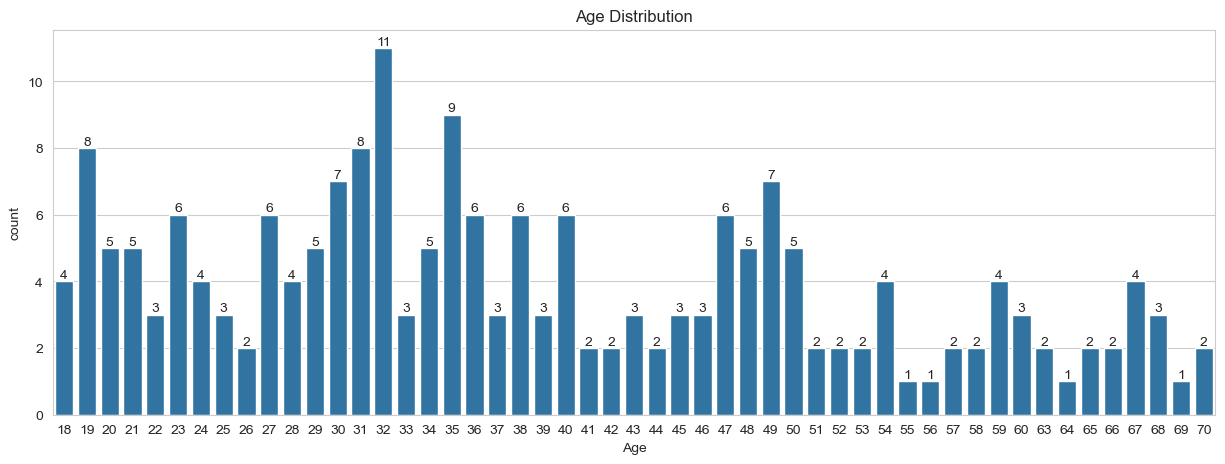

In [11]:
# We are investigating the age range of the customer group.
# Can we group customers by age?
# If we group customers by age and present it to them, what could the customer do?

plt.figure(figsize=(15,5))
ax = sns.countplot(x ='Age', data = df)
plt.title('Age Distribution')
plt.xlabel('Age')
ax.bar_label(ax.containers[0]);

# Most of the customers are in the 27-35 age group,
# followed by the 18-23 age group and the 48-50 age group.
# Based on this information alone, it can be said that the store should develop strategies targeting these age groups.

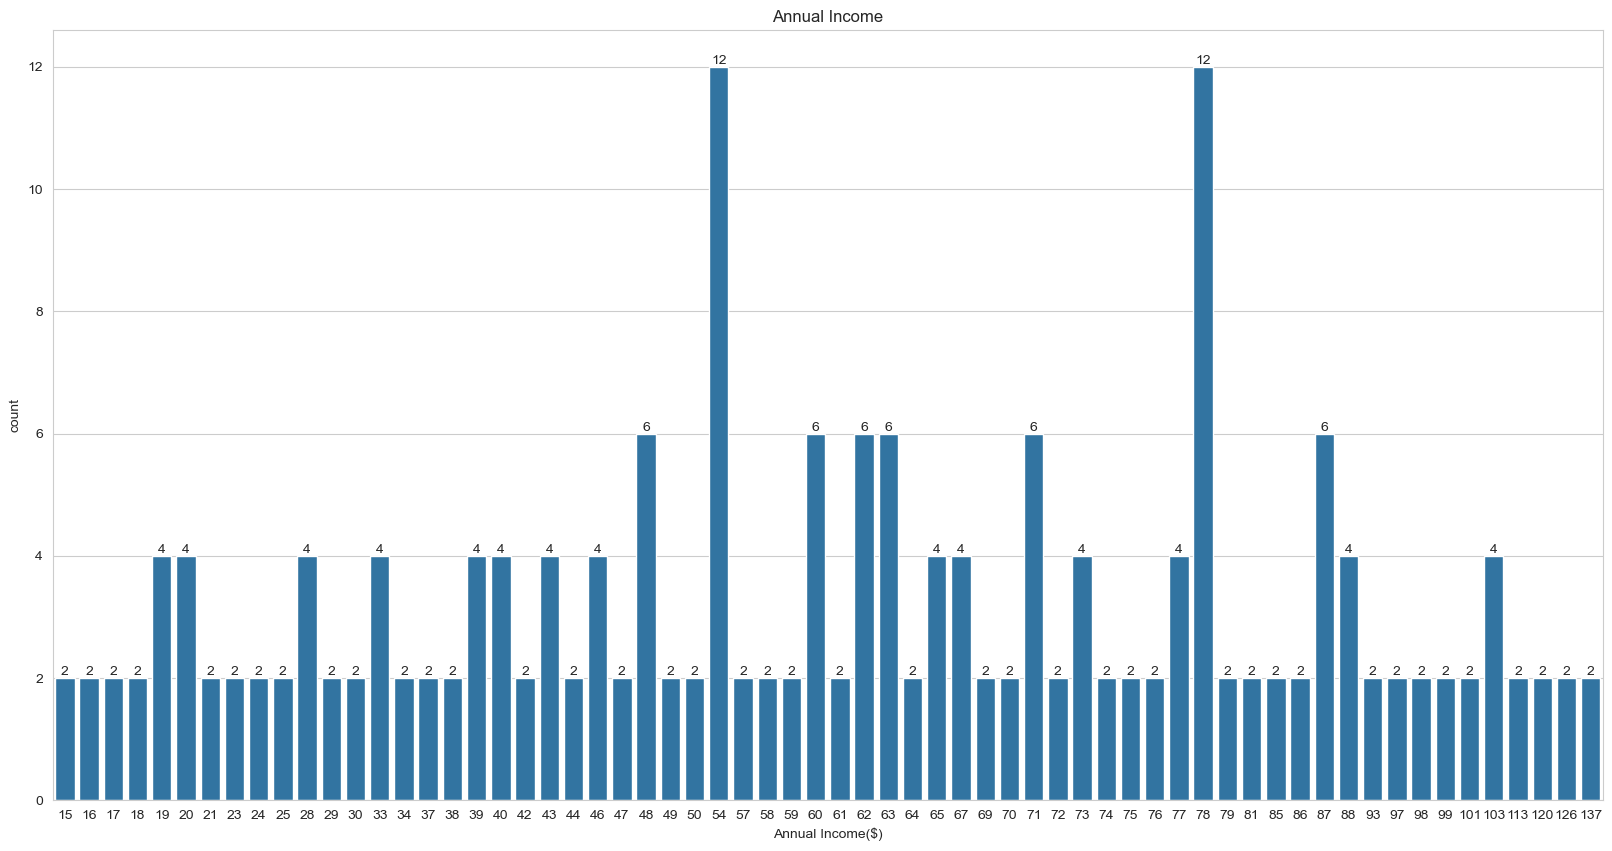

In [12]:
# We are investigating the annual incomes of the customer group.
# Can we group customers based on annual income?

plt.figure(figsize=(20,10))
ax = sns.countplot(x='Annual_Income', data=df)
plt.title('Annual Income')
plt.xlabel('Annual Income($)')
ax.bar_label(ax.containers[0]);

# Customers' annual incomes mostly range between $54,000 and $78,000.
# This means the store caters to a middle-income audience.

We see that the spending scores range between 35 and 60. Since the target customer base is middle-income, this is an expected situation. The store can develop strategies based on these spending scores.

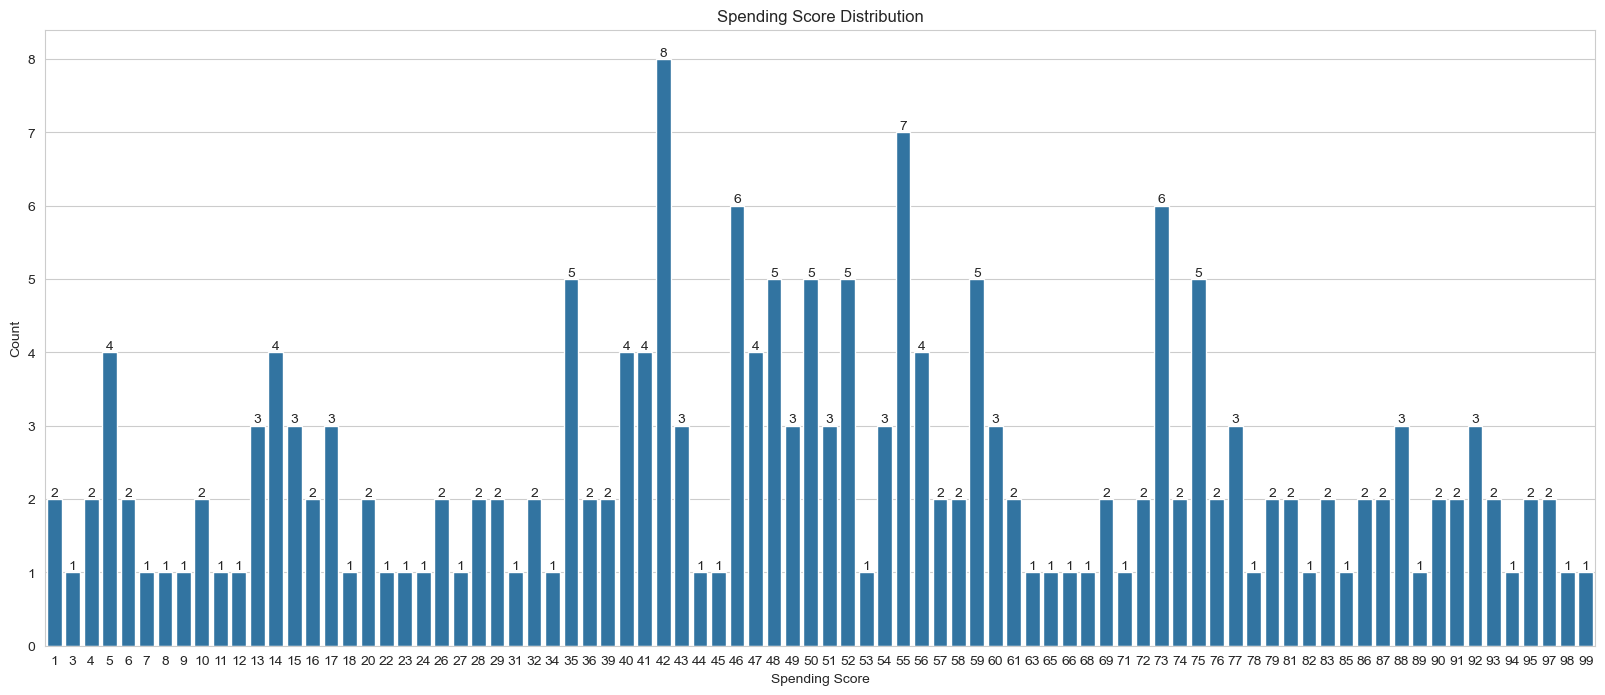

In [13]:
# We are investigating the spending scores of the customer group.

plt.figure(figsize=(20,8))
ax = sns.countplot(x='Spending_Score', data=df)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Count')
ax.bar_label(ax.containers[0]);

# We see that the spending scores range between 35 and 60.
# Since the target customer base is middle-income, this is an expected situation.
# The store can develop strategies based on these spending scores.

Let's review the insights we obtained above:

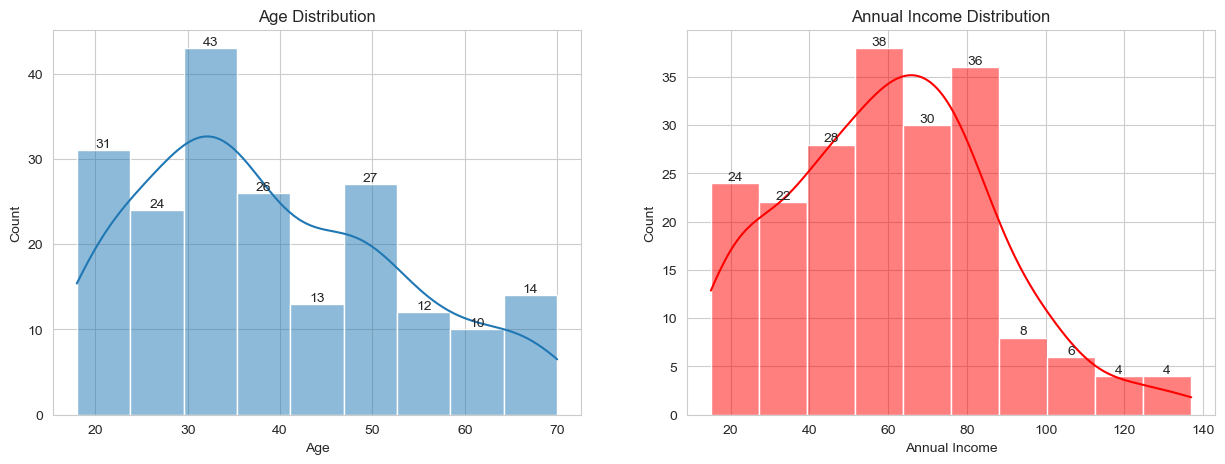

In [14]:
# We are looking at the densities of the age and annual income features.
# In which regions are the densities higher?

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
ax = sns.histplot(x='Age', data=df, kde =True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
ax.bar_label(ax.containers[0]);

plt.subplot(1,2,2)
ax = sns.histplot(x ='Annual_Income', data=df, color='red', kde = True)
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income')
plt.ylabel('Count')
ax.bar_label(ax.containers[0]);

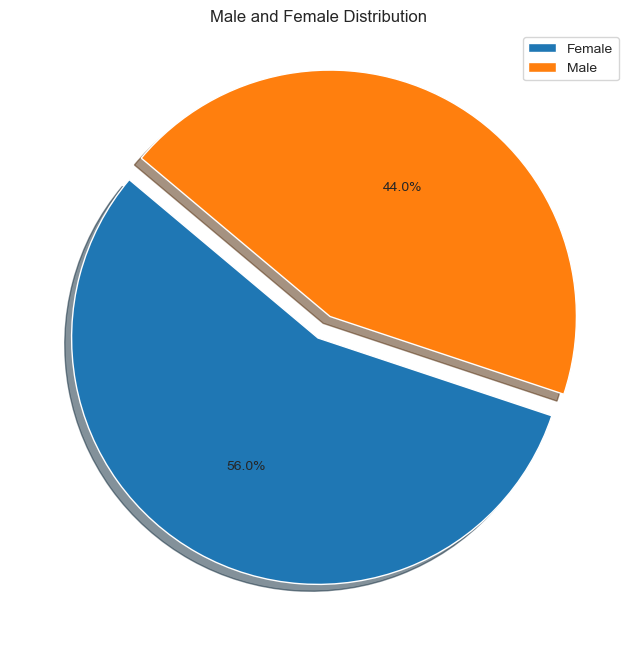

In [15]:
# We are comparing the gender ratios, which is one of the important aspects of customer segmentation.
# Could gender have an impact on spending potential? For instance, since most shoppers are women, strategies could be developed to retain female customers.
# Alternatively, campaigns could be created to encourage more shopping by men.
# Of course, the number shouldn't mislead us; qualitative shopping, like TV or makeup products, is also important.

plt.figure(figsize=(8,8))

explode = [0, 0.1]
plt.pie(df['Gender'].value_counts(), explode=explode, autopct='%1.1f%%', shadow=True,startangle=140)
plt.legend(labels=['Female','Male'])
plt.title('Male and Female Distribution')
plt.axis('off');

In [16]:
# correlatin among features

plt.figure(figsize=(15,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

# The negative correlation between age and spending score catches our attention; as age increases, the spending score decreases.
# We would expect higher spending with increased income, but there is no strong relationship between the two.
# This suggests that the higher-income segment is not spending more.

ValueError: could not convert string to float: 'Male'

<Figure size 1500x800 with 0 Axes>

In [ ]:
plt.figure(figsize=(15,5))
sns.stripplot(x='Gender', y='Spending_Score', data=df)
plt.title('Gender and Spending Score')
plt.show()


plt.figure(figsize=(15,5))
sns.boxplot(x='Gender', y='Spending_Score', data=df)
plt.title('Gender and Spending Score')
plt.show()

plt.figure(figsize=(15,5))
sns.violinplot(x='Gender', y='Spending_Score', data=df)
plt.title('Gender based Spending Score')
plt.show()

# Stripplot: Used to look at the density of categorical data.
# Since it provides both box plots and KDEs simultaneously,
# it allows us to see the density situation that was not visible in the box plot.

# Spending scores are concentrated between 40-60 for men, and between 40-60 and 80-90 for women.
# We can say that high spending scores are higher for women.

# In the boxplot, we also see the regions concentrated by gender.

# In the violinplot, we can view the information obtained from both stripplot and boxplot together.
# It allows us to observe both the concentrated regions and the whiskers in detail.
# Violinplot can be used to see where the density is concentrated.

In [ ]:
# let's see the distribution of annual_income of male and females using violin and box plots

plt.figure(figsize=(15,5))
sns.violinplot(x='Gender',y='Annual_Income', data=df)
plt.title('Gender based Annual Income Distribution')
plt.show()

plt.figure(figsize=(15,5))
sns.boxplot(x='Gender',y='Annual_Income', data=df)
plt.title('Gender based Annual Income Distribution')
plt.show()

# We see that the annual income is concentrated around $75,000 for both men and women.

In the pairplot, we cannot obtain any information between Age and Annual Income or Age and Spending Score, but there is a nice distribution between Annual Income and Spending Score. Based on the initial insights we obtained, we can say that we should form 5 groups.

In [ ]:
sns.pairplot(df);

# We look at the pairplot to get an idea of which variables to use and how many clusters we can create.
# We can get an idea of whether our data is inclined towards clustering and, if so, how many clusters we can divide it into by looking at the scatterplot.
# We should always keep in mind the ideal clustering principles: minimum intra-cluster distance and maximum inter-cluster distance.
# We cannot obtain any information between Age and Annual Income or Age and Spending Score, but there is a nice distribution between Annual Income and Spending Score.
# Based on the initial insights we obtained, we can say that we should form 5 groups.

In [ ]:
# Using Annual_Income and Spending_Score to create clustering, we look at the distribution of gender.
# In all groups, the distribution of men and women is almost equal, so there is no significant concentration on either side. Therefore, the gender distribution within groups will be balanced during clustering.

plt.figure(figsize=(16,8))

sns.scatterplot(x ='Annual_Income', y='Spending_Score', data=df, hue = "Gender")
plt.show()

- The group in the bottom left consists of low annual income and low spending.
- The group in the top left has low annual income but high spending.
- Since both of these groups have low income, they are not profitable.
- The group in the center has average annual income and average spending scores.
- The group in the bottom right has high annual income but low spending.
- The group in the top right has both high annual income and high spending.
- The group with high annual income and high spending will be the most profitable. Therefore, it is essential to ensure we do not lose these customers.
- Next, strategies should be developed for the group with high annual income but low spending.
- Efforts should be made to increase spending among average income groups.
- The group with low income but high spending should be retained, and small initiatives could encourage the group with low income and low spending to increase their spending.
- We have analyzed which features are more important for clustering here.

# Cluster Analysis

We will try two different methods in cluster analysis and compare them.

The first is **K-Means clustering**, and the other is **hierarchical clustering**.

We will start with KMeans.

**KMeans Clustering Theory**

- The goal is to divide observations into clusters based on their similarity to each other.

- We will specify the number of clusters in advance.

- We need to choose a value of k such that it represents the clustering of the dataset with minimum error.

- Minimum error is calculated by summing the errors within all clusters after calculating the intra-cluster errors.

- It assigns random centroids for each cluster. Then, it iteratively updates these centroids to the center of the clusters.

- It does this by calculating the distance of all observation points to all centroids. Observations are assigned to the nearest centroid.

- Within a cluster, the data's distance from the centroid determines whether the cluster is wide or narrow.

**Steps:**

- Specify the number of clusters.
- Randomly assign initial centroids based on the number of clusters.
- Calculate the distances of data observations to centroids and assign observations to the nearest centroids.
- Update the positions of centroids based on the distances between the assigned observations and centroids.
- Continue iterating and forming clusters.

We can perform multiple cluster analyses using different variables. For each cluster analysis, the most...

## Clustering based on Age and Spending Score - X1

- Since clustering quality deteriorates when performed across too many features, we will investigate which 2 features provide the highest quality clustering.

- First, let's examine the clustering quality between age and spending score.

**Important Note:**
- Our clustering methods work based on distance, so we need to scale our data.

- However, if all our features are within the same or similar range, scaling may not be necessary. In such cases, scaling can sometimes lead to worse results.

- We should try both scaled and unscaled data and proceed with the one that provides better results.

- Since the features in our dataset are generally within the same range, we will not perform scaling for this specific data.

### *i. Create a new dataset with two variables of your choice*

In [ ]:
df_2 = df.drop(columns="Gender")   

#In K-Means algorithms, we do not use categorical features.

In [ ]:
# We are checking how it works if we use only age and spending score here.
# Generally, clustering quality improves when we proceed with fewer features.

X1 = df.loc[:,['Age','Spending_Score']]
X1

**Hopkins Test**

- It is a statistical test that indicates how prone our data is to clustering.

- It provides a result on whether the data is uniformly distributed or randomly distributed.

- In a uniformly distributed data, since the data points are similar to each other, clustering is not feasible. Data that is prone to clustering is randomly distributed.

- Two hypotheses are proposed. The null hypothesis states that our data is uniform (non-random), while the alternative hypothesis suggests that our data is randomly distributed.

- If our score is below 0.5, meaning it is closer to zero, we say that the data is more prone to clustering.

In [ ]:
# Normally, this function is available in the `pyclustertend`'s Hopkins library. However, to avoid potential errors,
# we will use the function directly. Therefore, there is no need to install `pyclustertend`! 
                                                #!pip install pyclustertend --user
                                                # from pyclustertend import hopkins

from sklearn.neighbors import BallTree
import numpy as np
import pandas as pd
def hopkins(data_frame, sampling_size):
    """Assess the clusterability of a dataset. A score between 0 and 1, a score around 0.5 express
    no clusterability and a score tending to 0 express a high cluster tendency.
    Parameters
    ----------
    data_frame : numpy array
        The input dataset
    sampling_size : int
        The sampling size which is used to evaluate the number of DataFrame.
    Returns
    ---------------------
    score : float
        The hopkins score of the dataset (between 0 and 1)
    Examples
    --------
    >>> from sklearn import datasets
    >>> from pyclustertend import hopkins
    >>> X = datasets.load_iris().data
    >>> hopkins(X,150)
    0.16
    """
    if type(data_frame) == np.ndarray:
        data_frame = pd.DataFrame(data_frame)
    # Sample n observations from D : P
    if sampling_size > data_frame.shape[0]:
        raise Exception(
            'The number of sample of sample is bigger than the shape of D')
    data_frame_sample = data_frame.sample(n=sampling_size)
    # Get the distance to their neirest neighbors in D : X
    tree = BallTree(data_frame, leaf_size=2)
    dist, _ = tree.query(data_frame_sample, k=2)
    data_frame_sample_distances_to_nearest_neighbours = dist[:, 1]
    # Randomly simulate n points with the same variation as in D : Q.
    max_data_frame = data_frame.max()
    min_data_frame = data_frame.min()
    uniformly_selected_values_0 = np.random.uniform(min_data_frame[0], max_data_frame[0], sampling_size)
    uniformly_selected_values_1 = np.random.uniform(min_data_frame[1], max_data_frame[1], sampling_size)
    uniformly_selected_observations = np.column_stack((uniformly_selected_values_0, uniformly_selected_values_1))
    if len(max_data_frame) >= 2:
        for i in range(2, len(max_data_frame)):
            uniformly_selected_values_i = np.random.uniform(min_data_frame[i], max_data_frame[i], sampling_size)
            to_stack = (uniformly_selected_observations, uniformly_selected_values_i)
            uniformly_selected_observations = np.column_stack(to_stack)
    uniformly_selected_observations_df = pd.DataFrame(uniformly_selected_observations)
    # Get the distance to their neirest neighbors in D : Y
    tree = BallTree(data_frame, leaf_size=2)
    dist, _ = tree.query(uniformly_selected_observations_df, k=1)
    uniformly_df_distances_to_nearest_neighbours = dist
    # return the hopkins score
    x = sum(data_frame_sample_distances_to_nearest_neighbours)
    y = sum(uniformly_df_distances_to_nearest_neighbours)
    if x + y == 0:
        raise Exception('The denominator of the hopkins statistics is null')
    return x / (x + y)[0]

In [ ]:
# We are checking how prone our data is to clustering if we perform clustering using three features.
# If Hopkins is close to 0, we can say that our data is prone to clustering. If our data were very large, we could specify a `sampling_size` instead of using `X.shape[0]`.
# The reason for getting different results each time is that it randomly selects observations from X in the background.

hopkins(df_2, df_2.shape[0])

In [ ]:
# We obtained a slightly better score with two features.
hopkins(X1, X1.shape[0])

### *ii. Determine optimal number of clusters*

In [ ]:
sns.pairplot(X1);

# We are looking at the distributions of age and spending score.

**Elbow Method**

- Used to determine the optimal number of clusters.
- We run the model for different values of k.
- For each k value, the inertia (SSD) values obtained from our data are calculated and a graph is plotted.
- The k value corresponding to the elbow point where the inertia decreases most rapidly is the optimal k.
- The point where inertia is at its minimum corresponds to having as many clusters as there are observations, which is contrary to the clustering logic.

**SSD (Sum of Squared Distances) - Inertia**

- Used in the Elbow Method to determine the optimal k.
- It is calculated by taking the sum of the squares of the distances of each data point from the centroid.
- The goal is to minimize inertia. The iteration stops at the point of minimum inertia, resulting in the formation of clusters.
- The smaller the inertia, the closer our data points are to the centroid.

In [ ]:
from sklearn.cluster import KMeans

ssd =[]
for n in range(2,11):
    kmeans=KMeans(n_clusters=n,random_state=42)
    kmeans.fit(X1)
    ssd.append(kmeans.inertia_)
plt.figure(figsize=(10,6))
plt.plot(range(2, 11), ssd, "bo-")
plt.title('The Elbow Method')
plt.xlabel('No. of Clusters')
plt.ylabel('ssd')
plt.show()


# Note that we start the range from 2; if we start from 1, we will always see 2 as the optimal k from the elbow.
# Inertia calculates how well observations within clusters surround their centroids.
# Note that inertia focuses only on within-cluster distances.
# The smaller the inertia, the better the clusters surround their centroids.
# Here, we can say that the sharp drop occurs at 4.

# The elbow method is based on inertia and does not consider distances to other clusters.
# According to the elbow method, the "first" point where the sharp drop stops is the optimal k. Some datasets might have 2-3 sharp drops.
# The point where inertia is minimized corresponds to having as many clusters as there are observations, which is contrary to the logic of clustering.
# You can observe this by using `range(2,150)`.

In [ ]:
from sklearn.cluster import KMeans

ssd =[]
for n in range(2,11):
    kmeans=KMeans(n_clusters=n,random_state=42)
    kmeans.fit(X1)
    ssd.append(kmeans.inertia_)
plt.figure(figsize=(10,6))
plt.plot(range(2, 11), ssd, "bo-")
plt.title('The Elbow Method')
plt.xlabel('No. of Clusters')
plt.ylabel('ssd')
plt.show()


# Note that we start the range from 2; if we start from 1, we will always see 2 as the optimal k from the elbow.
# Inertia calculates how well observations within clusters surround their centroids.
# Note that inertia focuses only on within-cluster distances.
# The smaller the inertia, the better the clusters surround their centroids.
# Here, we can say that the sharp drop occurs at 4.

# The elbow method is based on inertia and does not consider distances to other clusters.
# According to the elbow method, the "first" point where the sharp drop stops is the optimal k. Some datasets might have 2-3 sharp drops.
# The point where inertia is minimized corresponds to having as many clusters as there are observations, which is contrary to the logic of clustering.
# You can observe this by using `range(2,150)`.

In [ ]:
ssd

In [ ]:
pd.Series(ssd).diff()

In [ ]:
df_diff =pd.DataFrame(-pd.Series(ssd).diff()).rename(index = lambda x : x+1)
df_diff

# Here, we can say that the sharp drop occurs at 4.

In [ ]:
df_diff.plot(kind='bar');

**Distortion Score**

- Used to find the optimal number of clusters (k).
- Unlike SSD, it calculates the average of the squared distances of each data point from the centroid by dividing the total sum by the number of observations.
- SSD-Inertia: Sums of the squared distances.
- Distortion: Sums of the averages of the squared distances.

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

kmeans = KMeans(random_state=42)
visu = KElbowVisualizer(kmeans, k = (2,10))
visu.fit(X1)
visu.poof();

# Yellowbrick considers not just the first point where a sharp drop stops, but the point where a meaningful drop stops, and provides recommendations based on that.
# I have obtained the necessary insights from pairplot, Hopkins, elbow method, and Yellowbrick, but to make a definitive decision, we will also look at the silhouette score.

**Silhouette Coefficient**: Indicates the quality of clustering.

- Used when we don't have labels or domain knowledge.

- First, it calculates the distances between all observations within a cluster.

- Then, it calculates the distances of observations within a cluster to observations in other clusters.

- A score is computed for each observation, and an average score is calculated for each cluster.

- A value close to 1 indicates good clustering.

- The goal is to have small distances within clusters and large distances between clusters.

- While inertia focuses on within-cluster distances, the Silhouette Coefficient focuses on between-cluster distances.

In [ ]:
# Silhouette Score is a metric that measures the quality of our clustering. Inertia measures how frequently each cluster is centered around its centroid (i.e., within-cluster distances). However, for ideal clustering, we also need to understand the maximal inter-cluster distance, and the Silhouette Score takes this into account.
# The closer the Silhouette Score is to 1, the higher the quality of the clustering.

from sklearn.metrics import silhouette_score
range_n_clusters = range(2,11)
for num_clusters in range_n_clusters:
    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(X1)
    cluster_labels = kmeans.labels_
    # silhouette score
    silhouette_avg = silhouette_score(X1, cluster_labels)
    print(f"For n_clusters={num_clusters}, the silhouette score is {silhouette_avg}")

In [ ]:
# With Yellowbrick's feature, we can see the Silhouette Scores for each cluster individually.
# After calculating our Silhouette Scores, we visualize these scores.
# We plotted for 4 clusters.
# The most observations are in the second cluster.
# The width of the scores indicates whether there are more or fewer observations.
# The red line represents the average Silhouette Score of all clusters.
# When looking at the distribution between clusters, we can say that all clusters are of similar quality.
from sklearn.cluster import KMeans

from yellowbrick.cluster import SilhouetteVisualizer

model3 = KMeans(n_clusters=4, random_state=42)
visualizer = SilhouetteVisualizer(model3)

visualizer.fit(X1)    # Fit the data to the visualizer
visualizer.poof();

In [ ]:
model3.n_clusters

In [ ]:
# We calculate the Silhouette Score for each cluster with this function.
# `model3.n_clusters`

for i in range(model3.n_clusters):
    label = (model3.labels_== i)
    print(f"mean silhouette score for label {i:<4} : {visualizer.silhouette_samples_[label].mean()}")
print(f"mean silhouette score for all labels : {visualizer.silhouette_score_}")

# The Elbow method and error metrics provide decision support points. 
# The final decision is made with domain knowledge and business insight.

## Why silhouette_score is negative?

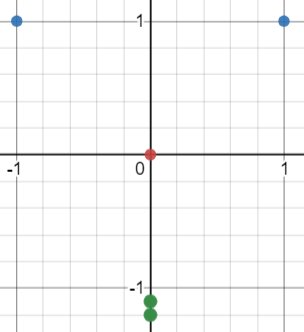

- Let's assume that the blues are one cluster and the greens are another cluster.
- The point at 0 is our new observation. We need to decide which cluster it belongs to.
- To determine which cluster a sample will be assigned to, we find the centroid of each cluster and assign the sample to the cluster whose centroid it is closest to.
- The centroid of the blue cluster is 1, and the centroid of the green cluster is slightly below -1.
- Since the blue centroid is closer to the sample, the sample is assigned to the blue cluster.
- One solution could be to increase the number of clusters.

**Silhouette Score Calculation:**

- **b**: The distance of the sample to the nearest cluster center (here b = 1).
- **a**: The average distance of the sample to the points within the same cluster (here a = √2 + √2 = 2√2 / 2 = √2).

**Silhouette Score** = (b - a) / max(a, b) = (1 - √2) / √2 = -0.29

- The green cluster is tightly clustered within itself, while the blue cluster has significant distances between its elements.
- If the Silhouette Score is negative, it means that the samples within that cluster are not well-clustered and are far from each other. This indicates that increasing the number of clusters may be necessary.
- A Silhouette Score close to or less than 0 suggests that the number of clusters should be increased.

**Silhouette Score Formula:**

- **silhouette_score** = (b - a) / max(a, b)

  - **b**: The mean nearest-cluster distance.
  - **a**: The mean intra-cluster distance.

### *iii. Apply K Means*

In [ ]:
kmeans = KMeans(n_clusters = 4, random_state=42)

# We decided on 4 clusters based on age and spending score.
# n_clusters=8 (default)
# n_init: Specifies how many times the centroid initialization process will be repeated.
# init='k-means++': Instead of random initialization, this tells the algorithm to start centroids in denser regions of the data.
# max_iter=300: This may need to be increased for larger datasets.
# random_state: Ensures the clusters are consistent across runs by fixing the random seed.

In [ ]:
kmeans.fit_predict(X1)    

# fit: The algorithm identifies patterns here (with 4 clusters). 
# Clusters are determined for each sample.

In [ ]:
X1["cluster_Kmeans"] = kmeans.fit_predict(X1) #kmeans.labels_

# We added the clusters we obtained from kmeans to the end of our data.
# We can see which cluster each sample went to in our data.

In [ ]:
X1

### *iv. Visualizing and Labeling All the Clusters*

In [ ]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='Age', y='Spending_Score', hue='cluster_Kmeans', data=X1, palette="bright")
centers = kmeans.cluster_centers_ # By writing this code on a separate line, it assigns centroids according to the number of clusters we have and returns them.
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=300, alpha=0.5);

# We are looking at the clusters and centroids formed based on age and spending score.
# We visualized according to the clusters we created and placed the centers on top.
# We asked for coloring based on `cluster_Kmeans`.
# In the clustering we did with Age and Spending_Score, we see that those with low spending scores are present in every age group.
# We see that those with spending scores between 40-60 are divided into two groups and vary between the 20-40 age group and the 40-70 age group.
# We also see that the age group with the highest spending score is between 20-40 years.
# Looking only from the age perspective, we see that spending scores are concentrated between 20-40 years.
# This indicates that younger people are more inclined to spend money. There is no group with high spending scores and older age.
# Spending policies can be developed for this group.
# People show certain shopping behaviors at specific age periods.

## Clustering based on Annual Income and Spending Score - X2

### *i. Create a new dataset with two variables of your choice*

In [ ]:
# Checking if we can obtain a higher quality result by performing a new clustering process with the Annual_Income and Spending_Score features

X2 = df.loc[:,['Annual_Income','Spending_Score']]
X2.head()

In [ ]:
hopkins(X2, X2.shape[0])

# When we used the other two features above, the Hopkins score was 0.29; here it’s a bit higher

### *ii. Determine optimal number of clusters*

In [ ]:
sns.pairplot(X2);

# checking the distribution of Annual_Income and Spending_Score

In [ ]:
ssd =[]
for n in range(2,11):
    kmeans=KMeans(n_clusters=n, random_state=42)
    kmeans.fit(X2)
    ssd.append(kmeans.inertia_)
plt.figure(figsize=(10,6))
plt.plot(range(2, 11), ssd, "bo-")
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('ssd')
plt.show()

# Here, it seems that the point where the decrease definitely stops is 5; we can choose 5 for the number of clusters.

In [ ]:
df_diff =pd.DataFrame(-pd.Series(ssd).diff()).rename(index = lambda x : x+1)
df_diff

# We can make the same inference by looking at the differences on SSD here. The sharp decrease stops at 5.

In [ ]:
# In the bar plot, we also see that the point where the sharp decrease stops is 5.
ax = df_diff.plot(kind='bar', figsize=(10,6))
ax.bar_label(ax.containers[0]);

In [ ]:
# The results also seem consistent in Yellowbrick.
from yellowbrick.cluster import KElbowVisualizer

kmeans = KMeans(random_state=42)
visu = KElbowVisualizer(kmeans, k = (2,10))
visu.fit(X2)
visu.poof()

In [ ]:
from sklearn.metrics import silhouette_score
range_n_clusters = range(2,11)
for num_clusters in range_n_clusters:
    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(X2)
    cluster_labels = kmeans.labels_
    # silhouette score
    silhouette_avg = silhouette_score(X2, cluster_labels)
    print(f"For n_clusters={num_clusters}, the silhouette score is {silhouette_avg}")

In [ ]:
# According to the Elbow method, Yellowbrick, and Silhouette score, the point where the sharp decrease stops is 5. 
# We are plotting the Silhouette scores with 5 clusters. 
# The cluster with the highest number of observations and the highest average Silhouette score appears to be cluster 0.
# The sample size of cluster 0 is larger compared to the other clusters.

model4 = KMeans(n_clusters=5, random_state=42)
visualizer = SilhouetteVisualizer(model4)

visualizer.fit(X2)    # Fit the data to the visualizer
visualizer.poof();

In [ ]:
#model3.n_clusters

for i in range(model4.n_clusters):
    label = (model4.labels_== i)
    print(f"mean silhouette score for label {i:<4} : {visualizer.silhouette_samples_[label].mean()}")
print(f"mean silhouette score for all labels : {visualizer.silhouette_score_}")

In [ ]:
from sklearn.metrics import silhouette_score
range_n_clusters = range(2,11)
for num_clusters in range_n_clusters:
    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(X2)
    cluster_labels = kmeans.labels_
    # silhouette score
    silhouette_avg = silhouette_score(X2, cluster_labels)
    print(f"For n_clusters={num_clusters}, the silhouette score is {silhouette_avg}")

### *iii. Apply K Means*

In [ ]:
# We have now decided that the number of clusters should be 5. We are creating our KMeans algorithm, fitting it, predicting, and obtaining our predictions.
kmeans2 = KMeans(n_clusters=5, random_state=42)
kmeans2.fit_predict(X2)          

In [ ]:
# We have added the clusters obtained from kmeans2 to the end of our data. 
# We can now see which cluster each sample belongs to in our data. 
# We will visualize our data with its clusters in this form.

X2['cluster_Kmeans'] = kmeans2.fit_predict(X2) #kmeans2.labels_
X2

### *iv. Visualizing and Labeling All the Clusters*

In [ ]:
plt.figure(figsize=(15,9))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='cluster_Kmeans', data=X2, palette="bright")
centers = kmeans2.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=300, alpha=0.5)

# We are looking at the clusters and centroids formed according to Annual_Income and Spending_Score. 
# Cluster 0 has been centered. 
# As we saw earlier, cluster 0 had the highest number of observations. 
# As observed, the orange cluster 1 has a high annual income but a very low spending score; we can create campaigns based on this. 
# The purple cluster 4 has both a high spending score and a high annual income. We need to work on retaining these customers. 
# Each cluster needs to be examined individually. 
# The red cluster 3 has a low annual income but a high spending score. These customers might shop frequently even if they don’t spend much per purchase. They might be tracking promotions and discounts. We need to develop a separate strategy for them.

# Hierarchical Clustering

- We have so far made our conclusions based on the KMeans algorithm. 
- We will also obtain and compare results using another clustering algorithm, Hierarchical Clustering. 
- We need to pay attention to the number of clusters in KMeans to identify differences.

**Hierarchical Clustering**
- The goal is to group observations based on their similarities.
- It is used when observations need to be divided into more granular clusters.
- In hierarchical clustering methods, the number of clusters is determined by looking at the dendrogram results, whereas in non-hierarchical methods, the number of clusters is specified before applying the method.
- We have two methods:

**Agglomerative Clustering**
- Bottom-up approach, the most commonly used method.
- It starts by treating each observation as its own cluster and then merges the closest clusters step by step until all observations are grouped into a single cluster.
- Initially, there are as many clusters as there are observations.
- The two closest observations in the dataset are found and merged to create a new observation, so the dataset now consists of these merged observations.
- This process is repeated by merging new clusters based on their similarities until all observations are in one cluster.

**Divisive Clustering**
- Top-down approach.
- It starts with one cluster containing all observations and splits it iteratively based on similarities until each observation is its own cluster or the desired number of clusters is achieved.

## Clustering based on Age and Spending Score- X1

In [ ]:
from scipy.cluster.hierarchy import linkage

# The dendrogram requires information on how distances will be measured when requesting the data.
# Therefore, both the data and the criteria for measuring distances are provided within the linkage function.
# Given this information, the dendrogram assigns observations to clusters and presents these assignments in a branching format.

**Looking at the hyperparameters of Hierarchical Clustering:**

**affinity** (proximity hyperparameter): Determines how the distance between observations is measured. Default: euclidean; others: manhattan, cosine, precomputed. If using ward, euclidean must be used.

**linkage**: Determines how an observation is linked to clusters. Default: ward; others: complete, average, single.

**ward**: Links observations in a way that minimizes variance. An observation is assigned to the cluster that reduces its variance the most.

- Variance: Zero variance indicates that all data points are equal, meaning there is no deviation from the mean.
- An increase in variance (magnitude) indicates that the data points are further from the mean (more spread out).
- If data clusters around the mean, variance is low.
- If data spreads out from the mean, variance is high.

**average**: The mean of each cluster is calculated, and the new observation is assigned to the cluster whose mean it decreases the most.

**complete**: Measures the distance between the new observation and the farthest observation in each cluster. The observation is assigned to the cluster with the shortest distance.

**single**: Measures the distance between the new observation and the closest observation in each cluster. The observation is assigned to the cluster with the shortest distance.

In [ ]:
hc_ward = linkage(y = X1, method = "ward")    # Assignment based on variance
hc_complete = linkage(X1, "complete")         # Assignment based on the farthest point
hc_average = linkage(X1, "average")           # Assignment based on the mean
hc_single = linkage(X1, "single")             # Assignment based on the closest point

# For these 4 different cases, we will visualize using the variables we created above.

In [ ]:
from scipy.cluster.hierarchy import dendrogram

# The dendrogram is similar to the Elbow method used in K-means. 
# By creating a hierarchical tree with the dendrogram and examining the distances between clusters, we decide how many clusters to choose. 
# We cannot provide the data directly into the dendrogram.

In [ ]:
# Here, we draw a dendrogram using our data for each linkage method. 
# When interpreting the dendrogram, distances are considered. We will prefer the method where the distance between clusters is the largest.
# Since Ward provides the minimum within-cluster variance and maximum between-cluster distance, we will continue with Ward.
# The number of clusters recommended by the dendrogram is shown by the blue line.
# However, the dendrogram suggests the number of clusters to maximize the distance between clusters, but we will also use scatter plots and silhouette scores to make our final decision.

# By setting `truncate_mode='lastp'` and `p=10`, we simplify the dendrogram to only show the last 10 clusters.

plt.figure(figsize = (20,12))

plt.subplot(221)
plt.title("Ward")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_ward, truncate_mode = "lastp", p = 10, show_contracted = True, leaf_font_size = 10)

plt.subplot(222)
plt.title("Complete")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_complete, truncate_mode = "lastp", p = 10, show_contracted = True, leaf_font_size = 10)

plt.subplot(223)
plt.title("Average")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_average, truncate_mode = "lastp", p = 10, show_contracted = True, leaf_font_size = 10)

plt.subplot(224)
plt.title("Single")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_single, truncate_mode = "lastp", p = 10, show_contracted = True, leaf_font_size = 10);

# We see that the maximum distance is with Ward, so we will proceed with Ward. 
# Ward suggests that we need to perform 2 clusterings. However, even when we choose 4 clusters, the distances between clusters are still quite large.
# There is no rule that dictates choosing the maximum distance; if a good separation is achieved, more clusters can be created.
# We have decided to set the number of clusters to 4.

In [ ]:
# Since we have chosen Ward as the linkage method, we redraw the dendrogram for a more detailed examination.
plt.figure(figsize = (20,8))
plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_ward, truncate_mode = "lastp", p = 10, show_contracted = True, leaf_font_size = 10);

In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
# Here, we will calculate the silhouette scores and compare them with the insights obtained from the dendrogram to decide on the number of clusters.

from sklearn.metrics import silhouette_score
range_n_clusters = range(2,11)
for num_clusters in range_n_clusters:
    # intialise kmeans
    Agg_model = AgglomerativeClustering(n_clusters=num_clusters)
    Agg_model.fit(X1)
    cluster_labels = Agg_model.labels_
    # silhouette score
    silhouette_avg = silhouette_score(X1, cluster_labels)
    print(f"For n_clusters={num_clusters}, the silhouette score is {silhouette_avg}")
    
# Since the highest score is 4, we will proceed with four clusters.

## Clustering based on Annual Income and Spending Score- X2

In [ ]:
# Let's also apply the Dendrogram method to the Annual_Income and Spending_Score features.
hc_ward = linkage(y = X2, method = "ward")
hc_complete = linkage(X2, "complete")
hc_average = linkage(X2, "average")
hc_single = linkage(X2, "single")

In [ ]:
plt.figure(figsize = (20,12))

plt.subplot(221)
plt.title("Ward")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_ward, truncate_mode = "lastp", p = 10, show_contracted = True, leaf_font_size = 10)

plt.subplot(222)
plt.title("Complete")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_complete, truncate_mode = "lastp", p = 10, show_contracted = True, leaf_font_size = 10)

plt.subplot(223)
plt.title("Average")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_average, truncate_mode = "lastp", p = 10, show_contracted = True, leaf_font_size = 10)

plt.subplot(224)
plt.title("Single")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_single, truncate_mode = "lastp", p = 10, show_contracted = True, leaf_font_size = 10);

# We observe that the maximum distance between clusters is with Ward, so we will proceed with it. 
# According to Ward, the most logical number of clusters is 3. However, even if we choose 5 clusters, the distances between clusters are still quite large, and the clusters are still well-separated.

In [ ]:
plt.figure(figsize = (20,8))
plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_ward, truncate_mode = "lastp", p = 10, show_contracted = True, leaf_font_size = 10);

In [ ]:
from sklearn.metrics import silhouette_score
range_n_clusters = range(2,11)
for num_clusters in range_n_clusters:
    # intialise kmeans
    Agg_model = AgglomerativeClustering(n_clusters=num_clusters)
    Agg_model.fit(X2)
    cluster_labels = Agg_model.labels_
    # silhouette score
    silhouette_avg = silhouette_score(X2, cluster_labels)
    print(f"For n_clusters={num_clusters}, the silhouette score is {silhouette_avg}")
    


## ii. *Apply Agglomerative Clustering*

### Age and Spending Score- X1

In [ ]:
# Here, we create our clustering algorithm and obtain clusters using `fit_predict`.
# Unlike K-means, Hierarchical Clustering does not have a `predict` feature and does not work independently.

Agg1 = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')
y_agg = Agg1.fit_predict(X1)

# When `linkage = "ward"`, `affinity='euclidean'` is mandatory due to the formulation of variance.

In [ ]:
# Here, we now have clusters obtained from both KMeans and Hierarchical Clustering. 
# The labels are different, but their positions are nearly the same (cluster_Kmeans vs. cluster_Agg).

X1['cluster_Agg'] = y_agg
X1.head()

### Annual Income and Spending Score- X2

In [ ]:
Agg2 = AgglomerativeClustering(n_clusters=5, affinity='euclidean', linkage='ward')
y_agg2 = Agg2.fit_predict(X2)

In [ ]:
# We had previously added the results from KMeans to X2. Now, let's also add our Agglomerative results to X2.
X2['cluster_Agg'] = y_agg2
X2.head()

## iii. *Visualizing and Labeling All the Clusters* 

### Age and Spending Score- X1

In [ ]:
# We visualized the clusters obtained from Agglomerative Clustering. We obtained a visualization similar to the one from KMeans.
plt.figure(figsize=(15,9))
sns.scatterplot(x='Age', y='Spending_Score', hue='cluster_Agg', data=X1, palette="bright");

In [ ]:
# We will visualize and compare the clusters obtained from both KMeans and Hierarchical Clustering. 
# We adjusted the colors with a palette to make it easier to compare clusters by coloring the same clusters with the same color.
# In KMeans, the boundaries of our clusters are clearer and more distinct.
# Agglomerative Clustering did not separate the blue and green groups very well.
# Considering this and other advantages, we are choosing KMeans.
plt.figure(figsize = (20,10))

plt.subplot(121)
sns.scatterplot(x='Age', y='Spending_Score', hue='cluster_Kmeans', data=X1, palette=['green','orange','brown',
                                                                             'dodgerblue'])
plt.title("K_means")
plt.subplot(122)
sns.scatterplot(x='Age', y='Spending_Score', hue='cluster_Agg', data=X1, palette=['dodgerblue','green',
                                                                              'orange','brown'])
plt.title("Agg")

### Annual Income and Spending Score- X2

In [ ]:
# the visual we obtained from agglomerative

plt.figure(figsize=(15,9))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='cluster_Agg', data=X2 ,palette="bright");

In [ ]:
# We compared the results of Agglomerative and K-means visually. 
# KMeans shows more distinct transitions. 
# We have ultimately chosen the KMeans algorithm.

plt.figure(figsize = (20,8))

plt.subplot(121)
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='cluster_Kmeans', data=X2, palette=['green', 'orange',
                                                            'brown','dodgerblue','red'])
plt.title("K_means")
plt.subplot(122)
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='cluster_Agg', data=X2, palette=['orange', 'green',
                                                            'red', 'dodgerblue', 'brown'])
plt.title("Agg")

# Conclusion

## Interpretation based on Age and Spending Score- X1

In [ ]:
X1.head()

In [ ]:
# We decided to use the values from KMeans. We see a balanced distribution in clustering. 
# We are counting customers by cluster for age and spending score.

X1.cluster_Kmeans.value_counts()

In [ ]:
# checking the number of customers with bar plot

plt.title("clusters with the number of customers")
plt.xlabel("clusters")
plt.ylabel("Count")
ax = X1.cluster_Kmeans.value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0]);

In [ ]:
df.head()

# Now, we will use the gender information from the original data to make evaluations.

In [ ]:
# We are adding the clusters obtained from KMeans (age-spending score) to our original data.
df["cluster_Age_Spending_Score"] = X1.cluster_Kmeans
df.head()

We separated the Spending Score by gender. We obtained insights into how spending scores are distributed by gender.

In [ ]:
# We separated the Spending Score by gender. 
# We obtained insights into the distribution of spending scores by gender.

plt.title("Men VS Women Ratio in Each Cluster")
plt.ylabel("Count")
ax = sns.countplot(x=df.cluster_Age_Spending_Score, hue=df.Gender)
for p in ax.containers:
    ax.bar_label(p)
    
# The higher number of women in clusters 2 and 3 is noticeable.

In [ ]:
# Here, we are grouping by the created clusters and calculating the average age, annual income, and spending score for each cluster.
df.groupby("cluster_Age_Spending_Score").mean()

In [ ]:
# Let's examine these evaluations using box plots. 
# Here, we need to assess each cluster within itself rather than comparing across different clusters.
# We have plotted the box plots for age, annual income, and spending score for each cluster.

plt.figure(figsize=(20,6))

plt.subplot(131)
sns.boxplot(y="Age", x="cluster_Age_Spending_Score", data=df)

plt.subplot(132)
sns.boxplot(y="Annual_Income", x="cluster_Age_Spending_Score", data=df)

plt.subplot(133)
sns.boxplot(y="Spending_Score", x="cluster_Age_Spending_Score", data=df);

# Group 0 consists of individuals over 50 years old, Group 1 is an intermediate age group, and Groups 2 and 3 are composed of younger individuals.
# For annual income, we see that there is not a very good separation; the data is generally clustered in the same range.
# In spending scores, the blue and pink groups might actually be the same group since their values are very close to each other.
# Clustering with 4 clusters does not seem very logical.

In [ ]:
# We can use violin plots to better visualize the distributions. 
# We can make the same observations as before based on these plots.

plt.figure(figsize = (20,6))

plt.subplot(131)
sns.violinplot(y = "Age", x = "cluster_Age_Spending_Score", data = df)

plt.subplot(132)
sns.violinplot(y = "Annual_Income", x = "cluster_Age_Spending_Score",  data = df)

plt.subplot(133)
sns.violinplot(y = "Spending_Score", x = "cluster_Age_Spending_Score", data = df);

In [ ]:
# Here, we see the distribution of each feature by group.

ax = df.groupby("cluster_Age_Spending_Score").mean().plot(kind='bar', figsize=(20,6))
for p in ax.containers:
    ax.bar_label(p, fmt="%.0f")  # Displaying the values without decimal places.

**Cluster 0**: Average age 56, average annual income 55,000, average spending score 48

**Cluster 3**: Average age 28, average annual income 53,000, average spending score 49

- Clusters 0 and 3 have the same annual incomes and spending scores. The only difference is the average age. The only thing distinguishing these two groups is age.

**Cluster 1**: Annual incomes are high but spending is very low. Among these four clusters, the first priority should be to increase the spending scores of this high-income group.

**Cluster 2**: Young, with high income and high spending. The store needs to retain this customer segment.

## Interpretation based on Annual Income and Spending Score- X2

In [ ]:
# Here, we will evaluate based on annual income and spending score.
X2

In [ ]:
# For X2, we are choosing K-means over Agglomerative Clustering. 
# We are counting customers by cluster for annual income and spending score.
# There is a concentration in Cluster 0. The counts for other clusters are similar. Let's visualize these values below.

X2.cluster_Kmeans.value_counts()

In [ ]:
plt.title("clusters with the number of customers")
plt.xlabel("clusters")
plt.ylabel("Count")
ax = X2.cluster_Kmeans.value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0]);

In [ ]:
df.head()

In [ ]:
df.drop(columns= "cluster_Age_Spending_Score", inplace=True)

# To extract results based on the clusters created with KMeans for Annual_Income and Spending_Score, we are dropping `cluster_Age_Spending_Score`.

In [ ]:
df["cluster_Annual_Income_Spending_Score"] = X2.cluster_Kmeans
df.head()

# adding cluster_Annual_Income_Spending_Score column

In [ ]:
# # We are counting the number of individuals in each cluster by gender.

plt.title("Men VS Women ratio in each cluster")
plt.ylabel("Count")
ax =sns.countplot(x=df.cluster_Annual_Income_Spending_Score, hue=df.Gender)
for p in ax.containers:
    ax.bar_label(p)

In [ ]:
# Here, we are grouping the dataframe both by Gender and `cluster_Annual_Income_Spending_Score`. 
# We are examining how to develop strategies based on age groups and genders.

df.groupby(["Gender", "cluster_Annual_Income_Spending_Score"]).mean()

In [ ]:
# We are visualizing the grouping we did above.
ax = df.groupby(["Gender", "cluster_Annual_Income_Spending_Score"]).mean().plot(kind="bar", figsize=(20,6))
for p in ax.containers:
    ax.bar_label(p, fmt="%.0f")

---

**Female 0**: Middle-aged group with high annual income. They can be encouraged to spend more.

**Female 1**: Very high annual income but low spenders. They should be targeted to increase their spending. (This group has the highest potential)

**Female 2**: Low income and low spending.

**Female 3**: Low income but high spending—ideal for targeted campaigns :)

We see similar groups for males as well. However, we can say that women tend to spend more than men.

In [ ]:
# # Here, we are examining each cluster by coloring them according to age, annual income, and spending score, with hue representing gender.

plt.figure(figsize = (20,6))

plt.subplot(131)
sns.boxplot(y = "Age", x = "cluster_Annual_Income_Spending_Score", hue= "Gender", data = df)

plt.subplot(132)
sns.boxplot(y = "Annual_Income", x = "cluster_Annual_Income_Spending_Score", hue= "Gender", data = df)

plt.subplot(133)
sns.boxplot(y = "Spending_Score", x = "cluster_Annual_Income_Spending_Score", hue= "Gender", data = df)

---

**Cluster 0**: Wide age range, average annual income, and average spending scores.

**Cluster 1**: Middle-aged, high annual income, and very low spending scores.

**Cluster 2**: Middle-aged and older, low annual income, and low spending scores.

**Cluster 3**: Young age range, low annual income, and very high spending scores.

**Cluster 4**: Average to slightly below average age range, high annual income, and high spending scores.

With 5 clusters, we can gain much more insight.

In [ ]:
plt.figure(figsize = (20,6))

plt.subplot(131)
sns.violinplot(y = "Age", x = "cluster_Annual_Income_Spending_Score", hue= "Gender", data = df)

plt.subplot(132)
sns.violinplot(y = "Annual_Income", x = "cluster_Annual_Income_Spending_Score", hue= "Gender", data = df)

plt.subplot(133)
sns.violinplot(y = "Spending_Score", x = "cluster_Annual_Income_Spending_Score", hue= "Gender", data = df)

In [ ]:
# Here, we see the distribution of each feature by group.

ax = df.groupby("cluster_Annual_Income_Spending_Score").mean().plot(kind='bar', figsize=(20,6))
for p in ax.containers:
    ax.bar_label(p, fmt="%.0f")

# Finally, we will summarize the insights obtained and present them to our client in the report.